<a href="https://colab.research.google.com/github/jezekvi/Spatial-Data-Science-with-Python/blob/main/4_dpz/dpz_reseni.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install rioxarray
import rioxarray as rxr
import xarray as xr
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.3 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [3]:
# Import dat

b2 = rxr.open_rasterio("/content/T33UVR_20250815T100559_B02_20m.jp2")
b3 = rxr.open_rasterio("/content/T33UVR_20250815T100559_B03_20m.jp2")
b4 = rxr.open_rasterio("/content/T33UVR_20250815T100559_B04_20m.jp2")
b8a = rxr.open_rasterio("/content/T33UVR_20250815T100559_B8A_20m.jp2")
scl = rxr.open_rasterio("/content/T33UVR_20250815T100559_SCL_20m.jp2")

In [8]:
print(f"souradnicovy system: {b2.rio.crs}")
print(f"rozsah: {b2.rio.bounds()}")
print(f"jednotky: {b2.rio.crs.linear_units}")
print(f"rozliseni pixelu: {b2.rio.resolution()}")
print(f"rozmer: {b2.shape}")
print(f"datovy typ: {b2.dtype}")

souradnicovy system: EPSG:32633
rozsah: (399960.0, 5490240.0, 509760.0, 5600040.0)
jednotky: metre
rozliseni pixelu: (20.0, -20.0)
rozmer: (1, 5490, 5490)
datovy typ: uint16


In [9]:
# Definice oblasti

min_x, min_y = 445000, 5525000
max_x, max_y = 480000, 5560000

b2_crop = b2.squeeze().rio.clip_box(minx = min_x, miny = min_y, maxx = max_x, maxy = max_y)
b3_crop = b3.squeeze().rio.clip_box(minx = min_x, miny = min_y, maxx = max_x, maxy = max_y)
b4_crop = b4.squeeze().rio.clip_box(minx = min_x, miny = min_y, maxx = max_x, maxy = max_y)
b8a_crop = b8a.squeeze().rio.clip_box(minx = min_x, miny = min_y, maxx = max_x, maxy = max_y)
scl_crop = scl.squeeze().rio.clip_box(minx = min_x, miny = min_y, maxx = max_x, maxy = max_y)

In [10]:
# Kalibrace

offset = -1000
scale = 10000

def calibrate(band):
  return (band.astype("float32") + offset) / scale

b2_cal = calibrate(b2_crop)
b3_cal = calibrate(b3_crop)
b4_cal = calibrate(b4_crop)
b8a_cal = calibrate(b8a_crop)

In [11]:
# Kontrola kalibrace

print(b2_crop.values[0,0])
print(b2_crop.dtype)

print(b2_cal.values[0,0])
print(b2_cal.dtype)

1252
uint16
0.0252
float32


rozmer: (3, 1750, 1750)


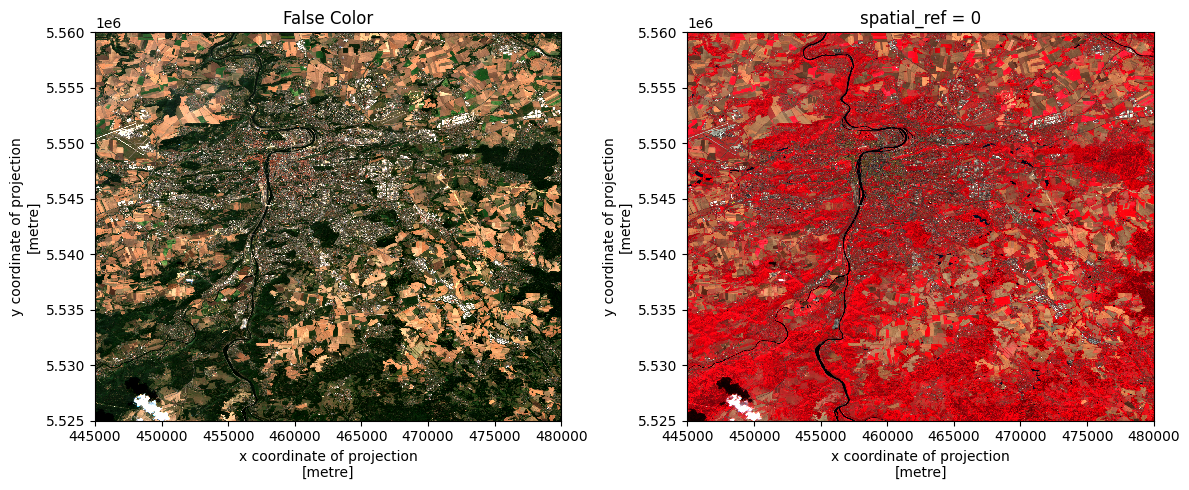

In [18]:
# Vizualizace

true = xr.concat([b4_cal, b3_cal, b2_cal], dim="band")
false = xr.concat([b8a_cal, b4_cal, b3_cal], dim="band")

print(f"rozmer: {true.shape}")

# Vykreslesni grafu

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

true.plot.imshow(ax=ax1, robust=True)
ax1.set_title("True Color")

false.plot.imshow(ax=ax2, robust=True)
ax1.set_title("False Color")

plt.tight_layout()
plt.show()


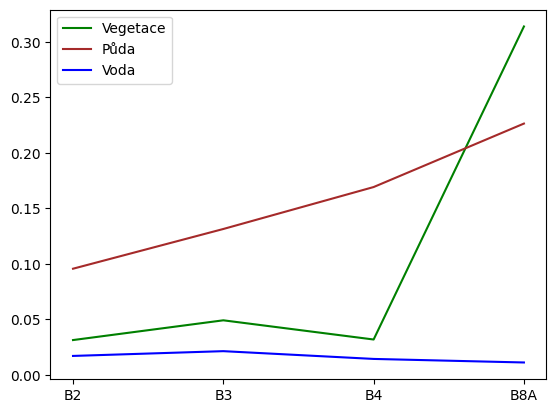

In [19]:
# Spektrální křivky

data_cube = xr.concat([b2_cal, b3_cal, b4_cal, b8a_cal], dim="band")

pixel_veg = data_cube.sel(x = 450000, y = 5530000, method = "nearest")
pixel_soil = data_cube.sel(x = 470000, y = 5533000, method = "nearest")
pixel_water = data_cube.sel(x = 454700, y = 5531000, method = "nearest")

bands = ["B2", "B3", "B4", "B8A"]

plt.plot(bands, pixel_veg, label = "Vegetace", color = "green")
plt.plot(bands, pixel_soil, label = "Půda", color = "brown")
plt.plot(bands, pixel_water, label = "Voda", color = "blue")

plt.legend()
plt.show()


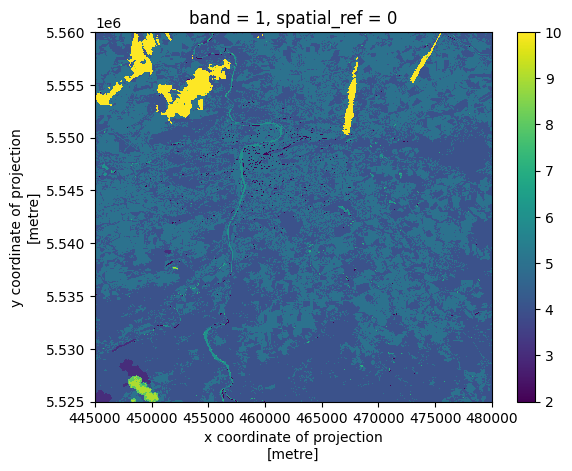

In [20]:
# Vizualizace pásma SCL

scl_crop.plot()

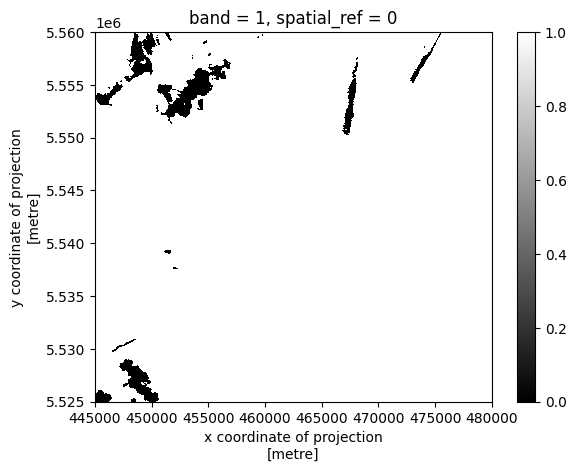

In [22]:
# Maska oblacnosti

mask = ~scl_crop.isin([3, 8, 9, 10])

red_clean = b4_cal.where(mask)
nir_clean = b8a_cal.where(mask)

mask.plot(cmap="gray")

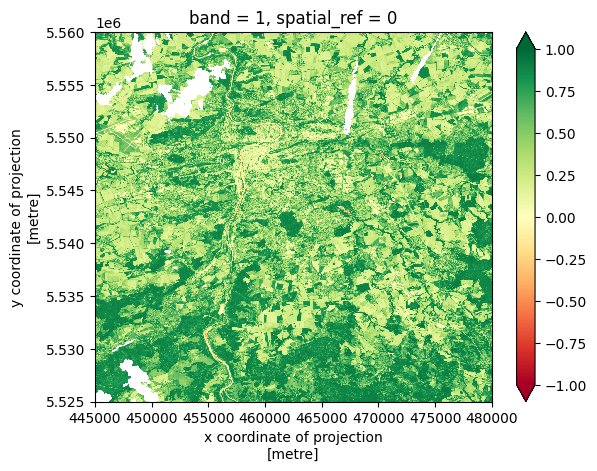

In [25]:
# NDVI = (NIR - Red) / (NIR + Red)

ndvi = (nir_clean - red_clean) / (nir_clean + red_clean)

ndvi.plot(cmap = "RdYlGn", vmin = -1, vmax = 1)

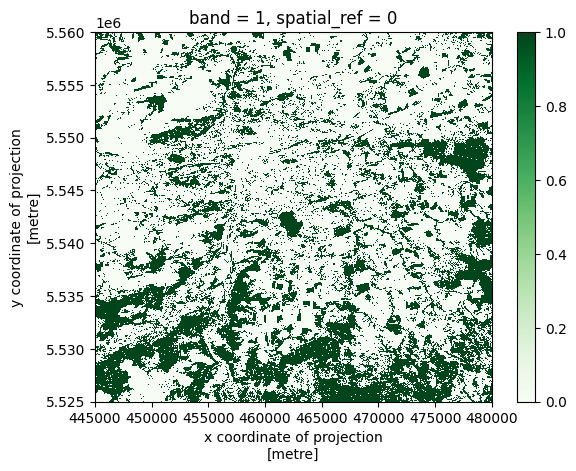

In [26]:
# Prahovani: NDVI > 0.7

threshold = 0.7
vegetation = (ndvi > threshold)

vegetation.plot(cmap = "Greens")

In [29]:
# Export

vegetation.astype("uint8").rio.to_raster("vegetation_mask.tif")